# Ejemplo práctico: árboles de clasificación en Scikit-Learn

Contenido:

1. El problema a resolver
2. Lectura y exploración del set de datos
3. Pre-procesamiento del set de datos
4. Entrenamiento del árbol de clasificación
5. Entrenamiento y validación
6. Prueba y análisis del desempeño del modelo entrenado



### Guía para Uso de Árboles de Decisión en Ciencia de Datos

Como científico de datos, necesitas entender cómo preparar tus datos para utilizar correctamente modelos como el **Árbol de Decisión**. Este modelo tiene ciertos requisitos y características que debemos tener en cuenta al trabajar con él, y es crucial saber cuándo **no** usarlo y por qué.

A continuación, te presento una guía completa que abarca desde los requisitos de los datos hasta las consideraciones adicionales que deben tomarse en cuenta cuando utilices un **Árbol de Decisión** para tus proyectos de ciencia de datos.

---

### 1. **Características de los Datos para Usar Árboles de Decisión**

#### A. **Distribución de los Datos**

* **Distribución Normal**: **NO es necesario** que los datos sigan una distribución normal. Los árboles de decisión no dependen de suposiciones sobre la distribución de los datos. Esto los hace **muy flexibles** y aptos para trabajar con **datos no lineales** y **no gaussianos**.

  * **Contrario a otros modelos**, como los modelos lineales o los modelos de regresión logística, que asumen una distribución normal, los árboles de decisión pueden manejar bien datos sesgados o distribuciones no normales.

#### B. **Escala de los Datos**

* **Escala de Características**: **NO es necesario** que los datos estén **escalados** (normalizados o estandarizados). Los árboles de decisión funcionan bien sin necesidad de escalar las características.

  * Esto se debe a que el algoritmo de **árboles de decisión** divide los datos basándose en umbrales específicos (por ejemplo, "¿Es esta característica mayor que 5?"), lo que hace que la escala de las variables no afecte al modelo.
  * **Excepción**: Si usas **regresores** o **árboles con características continuas** muy dispares, puedes hacer una normalización para facilitar la interpretación o evitar que una variable domine el modelo.

#### C. **Tipos de Datos: ¿Solo Numéricos?**

* **Datos Numéricos y Categóricos**: Los árboles de decisión pueden manejar tanto **datos numéricos** como **categóricos**. Esto les permite ser muy versátiles.

  * **Datos Categóricos**: El modelo puede dividir los datos en diferentes grupos basados en las categorías (por ejemplo, "Color = Rojo", "Color = Verde").
  * **Datos Numéricos**: El modelo divide los datos en intervalos (por ejemplo, "Edad > 30" o "Ingresos < 50,000").

#### D. **Manejo de Valores Faltantes (Missing Values)**

* **No maneja bien valores nulos**: Si tus datos contienen valores faltantes, debes tratarlos antes de usar el árbol de decisión. Los árboles de decisión no manejan los valores nulos directamente y pueden producir errores si los datos no están completos.

  * **Soluciones**: Imputar los valores faltantes usando la **media**, **mediana** o utilizando **modelos de imputación** más complejos si es necesario.

#### E. **¿Son los Datos Sensibles al Desbalance?**

* **Desbalance de Clases**: Los árboles de decisión pueden **ser sensibles al desbalance de clases** en problemas de clasificación.

  * Si tienes una clase muy dominante, el árbol puede tender a predecir siempre la clase mayoritaria.
  * **Soluciones**:

    * **Balanceo de datos**: Usar técnicas como **SMOTE** (Synthetic Minority Over-sampling Technique) para balancear las clases.
    * **Peso de las clases**: Ajustar los pesos de las clases dentro del modelo (`class_weight='balanced'` en `DecisionTreeClassifier`).
    * **Submuestreo** o **sobremuestreo**: Para tener una representación más equitativa de cada clase.

---

### 2. **Consideraciones Adicionales al Usar Árboles de Decisión**

#### A. **Necesidad de Preprocesamiento**

* **Transformaciones**: En general, los árboles de decisión requieren muy poco preprocesamiento de los datos en comparación con otros modelos. No es necesario realizar:

  * **Transformación logarítmica** para normalizar distribuciones.
  * **Codificación One-Hot** para variables categóricas (el árbol puede trabajar con variables categóricas directamente).
  * **Escalado o normalización** de las variables numéricas.

#### B. **Sobreajuste (Overfitting)**

* **Riesgo de Sobreajuste**: Los árboles de decisión tienen una alta propensidad a **sobreajustar** (overfitting) si no se regulan adecuadamente. Esto sucede especialmente si el árbol es **demasiado profundo** o si no hay suficientes muestras por hoja.

  * **Solución**: Utiliza **pruning** (poda) para recortar ramas que no aporten valor, o limita la **profundidad máxima** del árbol utilizando el parámetro `max_depth`.
  * También puedes controlar el tamaño de las hojas con `min_samples_leaf` para evitar ramas que se basan en muy pocas observaciones.

#### C. **Interpretabilidad**

* **Fácil Interpretación**: Uno de los mayores puntos a favor de los árboles de decisión es que son **altamente interpretables**. A diferencia de otros modelos complejos (como las redes neuronales), puedes visualizar el árbol y entender cómo toma decisiones, lo cual es muy útil para comunicar resultados a partes interesadas.

---

### 3. **¿Cuándo NO Usar un Árbol de Decisión?**

#### A. **Relaciones No Lineales Complejas**

* Si tus datos tienen relaciones muy **no lineales** o **altamente interactivas** entre las variables, el árbol de decisión puede no ser la mejor opción.

  * **Alternativas**: Modelos como **Redes Neuronales**, **Support Vector Machines (SVM)** o **K-Nearest Neighbors (KNN)** pueden capturar mejor estas relaciones.

#### B. **Datos con Demasiados Outliers o Ruido**

* Los árboles de decisión son **muy sensibles al ruido** en los datos. Si tienes muchos **outliers** (valores atípicos), estos pueden hacer que el árbol cree ramas innecesarias que no representen patrones verdaderos.

  * **Alternativas**: Modelos más robustos como **Random Forests** o **Gradient Boosting Machines** pueden ser más adecuados para manejar estos casos.

#### C. **Altos Costos de Computación**

* Si estás trabajando con **grandes volúmenes de datos** o **muchas características**, el árbol de decisión puede volverse **costoso** en términos de memoria y tiempo de cálculo, especialmente si no se limita su crecimiento.

  * **Alternativa**: Usar un modelo de **ensemble** como **Random Forest** o **XGBoost**, que es más eficiente y maneja grandes volúmenes de datos de manera más eficaz.

#### D. **Relaciones entre Características No Capturadas**

* Si las relaciones entre características son **altamente interdependientes** y no pueden ser capturadas por un simple árbol, este modelo podría no ser el adecuado.

  * **Alternativas**: Usar modelos como **SVM** o **Redes Neuronales** para capturar estas relaciones complejas.

---

### 4. **Conclusión: ¿Cuándo Usar un Árbol de Decisión?**

Los árboles de decisión son ideales para problemas con datos **tabulares** que contienen tanto variables numéricas como categóricas, siempre y cuando no haya una relación extremadamente no lineal entre las variables. Son especialmente útiles cuando se necesita un modelo **interpretativo** y cuando no se requiere un ajuste perfecto a los datos (es decir, cuando no hay un riesgo de sobreajuste).

Recuerda siempre controlar la **profundidad del árbol**, asegurarte de que los datos estén **limpios** (sin valores nulos) y considerar el **balance de clases** si tienes un problema de clasificación con clases desbalanceadas.

Si sigues estas pautas, tendrás un modelo de árbol de decisión eficiente y robusto.


## 1. El problema a resolver

El objetivo de esta práctica es entrenar, validar y poner a prueba un árbol de clasificación capaz de determinar si un vehículo sería una buena adquisición dadas características como su precio, su costo de mantenimiento y otros parámetros adicionales.

## 2. Lectura y exploración del set de datos

Usaremos el set de datos "vehiculos.csv" que contiene información acerca de las características de diferentes vehículos (precio, costo del mantenimiento, número de puertas, número de pasajeros, tamaño del baúl y nivel de seguridad que ofrece) y por cada uno indica si se trata de un vehículo con categoría "inaceptable", "aceptable", "bueno" o "muy bueno".

Comencemos importando Pandas para leer y explorar el set de datos:

In [1]:
import pandas as pd

RUTA = ''
df = pd.read_csv(RUTA + 'vehiculos.csv')
df

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad,categoria
0,muy_alto,muy_alto,2,2,pequeno,media,inaceptable
1,muy_alto,muy_alto,2,2,pequeno,alta,inaceptable
2,muy_alto,muy_alto,2,2,mediano,baja,inaceptable
3,muy_alto,muy_alto,2,2,mediano,media,inaceptable
4,muy_alto,muy_alto,2,2,mediano,alta,inaceptable
...,...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media,bueno
1723,bajo,bajo,5+,4+,mediano,alta,muy_bueno
1724,bajo,bajo,5+,4+,grande,baja,inaceptable
1725,bajo,bajo,5+,4+,grande,media,bueno


Verifiquemos si el set contiene datos faltantes:

In [2]:
# Datos faltantes
df.isna().sum()

precio           0
mantenimiento    0
nro_puertas      0
pasajeros        0
baul             0
seguridad        0
categoria        0
dtype: int64

El dataset no contiene datos faltantes. Verifiquemos qué tipos de datos tenemos por cada columna:

In [3]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   precio         1727 non-null   object
 1   mantenimiento  1727 non-null   object
 2   nro_puertas    1727 non-null   object
 3   pasajeros      1727 non-null   object
 4   baul           1727 non-null   object
 5   seguridad      1727 non-null   object
 6   categoria      1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


Todas las características (variables predictoras) son categóricas y lo mismo ocurre con la variable a predecir (la columna "categoria").

Más adelante tendremos que pre-procesar estas variables para convertirlas a su representación numérica pero por ahora veamos los niveles de cada una de estas variables:

In [4]:
# Información variables categóricas
for col in df.columns:
    print(df[col].value_counts())
    print('-'*20)

precio
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
mantenimiento
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
nro_puertas
3     432
4     432
5+    432
2     431
Name: count, dtype: int64
--------------------
pasajeros
4     576
4+    576
2     575
Name: count, dtype: int64
--------------------
baul
mediano    576
grande     576
pequeno    575
Name: count, dtype: int64
--------------------
seguridad
media    576
alta     576
baja     575
Name: count, dtype: int64
--------------------
categoria
inaceptable    1209
aceptable       384
bueno            69
muy_bueno        65
Name: count, dtype: int64
--------------------


Ya tenemos una idea clara de nuestro set de datos. Es importante resaltar que está **desbalanceado**, es decir que las categorías en las que queremos clasificar cada dato no están equilibradas.

Idealmente deberíamos buscar tener un set de datos balanceado y, de no ser posible, es importante tomar nota de este comportamiento al momento de pre-procesar los datos y de entrenar, validar y poner a prueba el modelo.

## 3. Pre-procesamiento del set de datos

En esta sección:

- Crearemos los sets X y Y. El primer arreglo contendrá las variables predictoras (primeras 6 columnas) y el segundo la variable a predecir (la última columna)
- Generaremos la partición del set de datos en entrenamiento/validación y prueba. El primer subset será usado, como su nombre lo indica, para entrenar y validar el modelo. El segundo se mantendrá oculto y cuando hayamos entrenado el modelo le presentaremos este subset para ponero a prueba.
- Codificaremos númericamente las variables categóricas (arreglo X) y la variable a predecir (arreglo Y)

Veamos cada uno de estos pasos, comenzando con la creación de los sets X y Y:

In [5]:
# Característica (o variables predictoras)
x = df.iloc[:,:-1]
x

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [6]:
# Variable a predecir
y = df.iloc[:,-1]
y

0       inaceptable
1       inaceptable
2       inaceptable
3       inaceptable
4       inaceptable
           ...     
1722          bueno
1723      muy_bueno
1724    inaceptable
1725          bueno
1726      muy_bueno
Name: categoria, Length: 1727, dtype: object

A continuación creamos el set de entrenamiento/validación y el set de prueba. Este último tendrá un 10% del total de datos.

Es importante en este punto tener en cuenta que el set de datos está **desbalanceado** así que al conformar los sub-sets debemos **garantizar que se mantiene la proporción de las categorías**:

In [7]:
# Partir en entrenamiento/validación y prueba
from sklearn.model_selection import train_test_split

x_trvl, x_ts, y_trvl, y_ts = train_test_split(x, y, 
                                          test_size=0.1, # Tamaño del set de prueba: 10% del total 
                                          random_state=123, # Para reproducibilidad
                                          stratify=y, #Mantener la proporción de las categorías
                                          )

# Imprimir en pantalla los tamaños de los sets que acabamos de crear
print('Tamaño set de entrenamiento/validación: ', x_trvl.shape, y_trvl.shape)
print('Tamaño set de prueba: ', x_ts.shape, y_ts.shape)

# E imprimir la proporción de categorías tanto en entrenamiento/validación como en prueba
print('Proporción de categorías en el set de entrenamiento/validación:')
print(y_trvl.value_counts(normalize=True))

print('Proporción de categorías en el set de prueba:')
print(y_ts.value_counts(normalize=True))

Tamaño set de entrenamiento/validación:  (1554, 6) (1554,)
Tamaño set de prueba:  (173, 6) (173,)
Proporción de categorías en el set de entrenamiento/validación:
categoria
inaceptable    0.700129
aceptable      0.222651
bueno          0.039897
muy_bueno      0.037323
Name: proportion, dtype: float64
Proporción de categorías en el set de prueba:
categoria
inaceptable    0.699422
aceptable      0.219653
bueno          0.040462
muy_bueno      0.040462
Name: proportion, dtype: float64


Perfecto. Ya hemos creado los sets de entrenamiento/validación y de prueba y hemos garantizado que se mantienen las proporciones originales en cada categoría.

Ahora veamos cómo codificar numéricamente el arreglo "x", variables predictoras:

In [8]:
print(x)

        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande      baja
1725      bajo          bajo          5+        4+   grande     media
1726      bajo          bajo          5+        4+   grande      alta

[1727 rows x 6 columns]


La idea de esta codificación es simple. En cada columna las variables categóricas son ordinales (bajo, medio, alto, muy_alto; pequeño, mediano, grande; media, baja, alta, etc.) así que se realizará **codificación ordinal**.

En esta codificación ordinal cada nivel será codificado con un número y estos números tendrán un orden específico. Por ejemplo:

bajo --> 0
medio --> 1
alto --> 2
muy_alto --> 3

Y esto lo podemos lograr de forma muy sencilla usando "OrdinalEncoder" de Scikit-Learn:

In [9]:
# Codificación ordinal de las variables predictoras
# NOTA IMPORTANTE: se define la codificación con base en el set de entrenamiento/validación
# pues es el set de datos "conocido" (el otro se mantiene "oculto")
from sklearn.preprocessing import OrdinalEncoder

# Codificar el set de entrenamiento/validación ("x_trvl")
x_encoder = OrdinalEncoder()
X = x_encoder.fit_transform(x_trvl)

# Veamos las categorías tenidas en cuenta por el codificador y el resultado de la codificación
print(x_encoder.categories_)
print(X)


[array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['2', '3', '4', '5+'], dtype=object), array(['2', '4', '4+'], dtype=object), array(['grande', 'mediano', 'pequeno'], dtype=object), array(['alta', 'baja', 'media'], dtype=object)]
[[2. 0. 3. 2. 1. 0.]
 [0. 3. 3. 1. 2. 0.]
 [0. 2. 2. 1. 2. 2.]
 ...
 [3. 2. 0. 1. 1. 1.]
 [2. 1. 1. 2. 0. 2.]
 [1. 3. 0. 1. 0. 2.]]


Perfecto. Ahora hacemos algo similar con la variable a predecir pero en este caso usaremos "LabelEncoder" que codifica numéricamente cada una de las categorías que queremos predecir:

In [10]:
# Al igual que en el caso anterior, se usa únicamente el set de entrenamiento/validación
# como referencia para el codificador
from sklearn.preprocessing import LabelEncoder

# Codificar set de entrenamiento/validación
y_encoder = LabelEncoder()
Y = y_encoder.fit_transform(y_trvl)

# E imprimir en pantalla las categorías consideradas por el codificador así como el resultado
# de la codificación
print(y_encoder.classes_)
print(Y)

['aceptable' 'bueno' 'inaceptable' 'muy_bueno']
[0 2 2 ... 2 1 0]


Y en este punto ya tenemos los datos listos para poder construir y entrenar el modelo. Veamos cómo hacerlo.

## 4. Entrenamiento del árbol de clasificación

En este punto veremos cómo entrenar el árbol de clasificación usando Scikit-Learn y el algoritmo CART y cuáles son los parámetros que usualmente podremos definir en esta fase. Además veremos cómo graficar el árbol entrenado para ver en detalle sus características.

Comencemos construyendo un árbol básico:

In [11]:
from sklearn.tree import DecisionTreeClassifier

# Crear instancia del clasificador y entrenar con el set de entrenamiento/validación (X,Y)
arbol = DecisionTreeClassifier()
arbol.fit(X,Y)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


¡Y es así de simple, con tan sólo 2 líneas de código!

Para graficar el árbol podemos usar el módulo "tree" de scikit-learn:

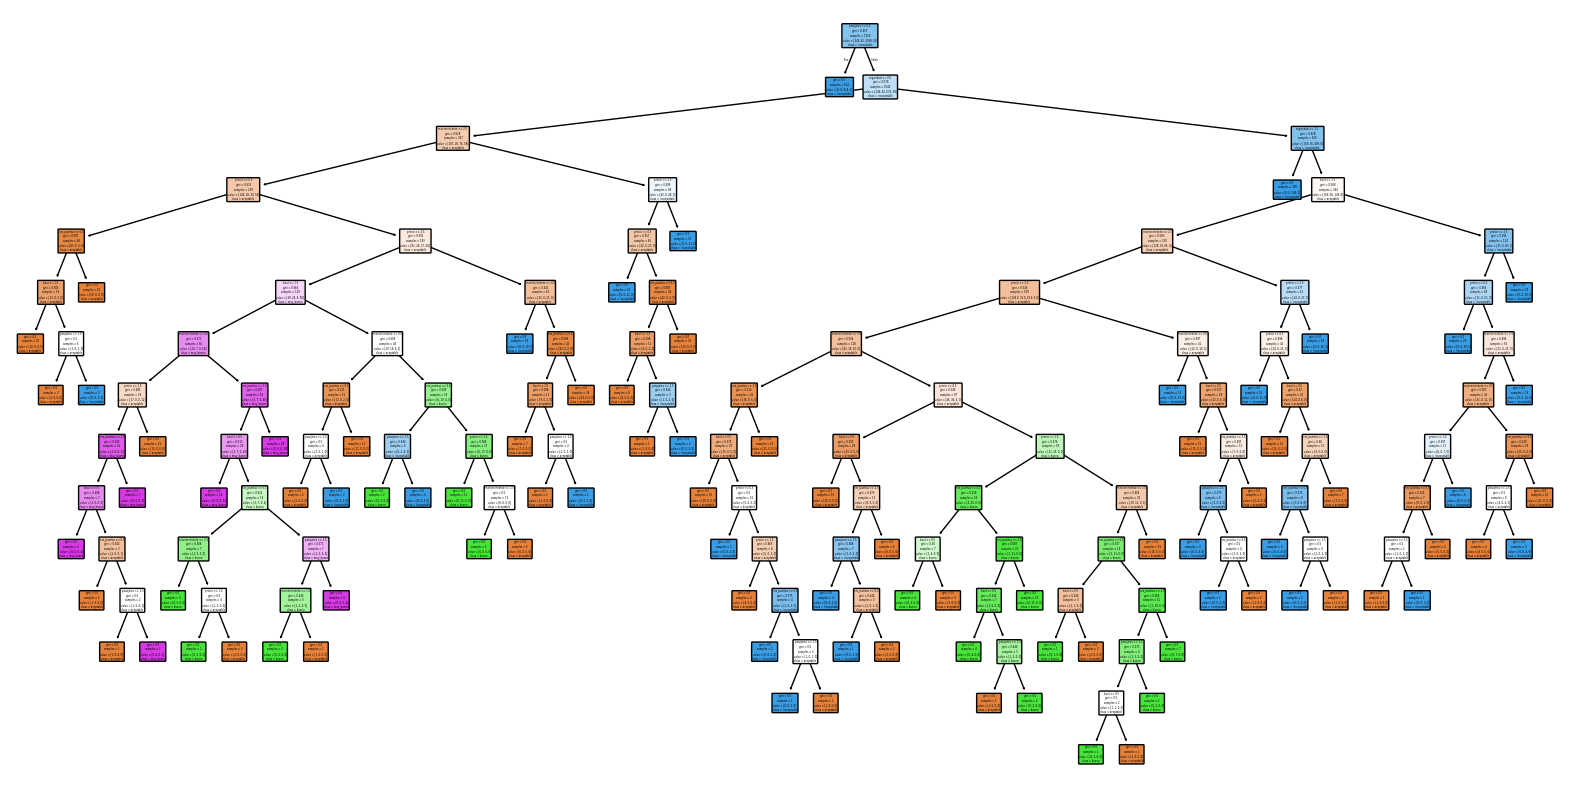

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Tamaño de la figura
tree.plot_tree(arbol,
               feature_names=x_encoder.get_feature_names_out(), # Para que contenga los nombres de las características
               class_names = y_encoder.classes_, # Para que contenga los nombres de las categorías
               filled=True,  # Colorear las hojas con la categoría mayoritaria
               rounded=True, # Bordes redondeados
               );

Es un árbol bastante grande pero podemos ver todas las rutas que se pueden tomar al momento de clasificar un dato.

Veamos algunas características de este árbol:

In [13]:
# Características del árbol
print(f'Profundidad del árbol: {arbol.get_depth()}')
print(f'Parámetros usados en el entrenamiento: {arbol.get_params()}')

Profundidad del árbol: 14
Parámetros usados en el entrenamiento: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


Podemos entrenar un nuevo árbol pero añadiendo algunos parámetros adicionales:

- "max_depth": controla la profundidad del árbol construido. Fijaremos un valor de 5 para este parámetro
- "random_state": es la semilla del generador aleatorio. Se usa para determinar desempates en casos en los cuales tengamos hojas con la misma cantidad de datos de las diferentes categorías o cuando el algoritmo CART tenga que decidir entre una partición u otra que generan el mismo índice Gini (o entropía). La idea es poner este valor en una cantidad numérica fija para que siempre que entrenemos el árbol obtengamos exactamente la misma estructura. Fijaremos este valor en 123

Profundidad del árbol: 5


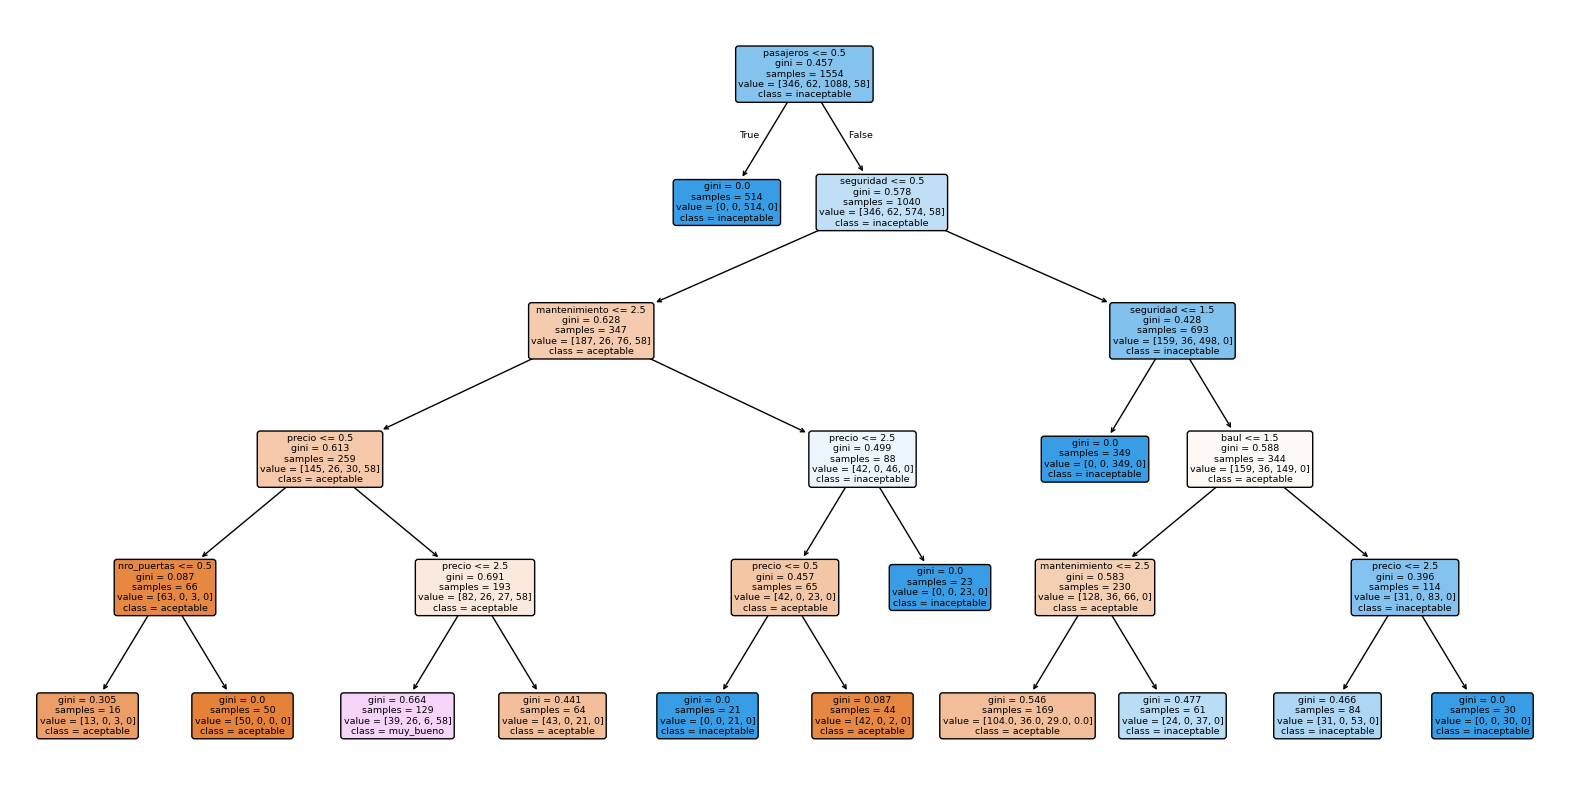

In [14]:
# Reentrenar pero con una profundidad máxima de 5
arbol = DecisionTreeClassifier(max_depth=5,
                               random_state=123)
arbol.fit(X,Y)

# Graficar
plt.figure(figsize=(20, 10))
tree.plot_tree(arbol,
               feature_names=x_encoder.get_feature_names_out(),
               class_names = y_encoder.classes_,
               filled=True,
               rounded=True);

print(f'Profundidad del árbol: {arbol.get_depth()}')

Y en este punto ya tenemos claros los elementos básicos para entrenar un árbol. Sin embargo, el entrenamiento que acabamos de ver no es suficiente pues no conocemos aún el desempeño de este árbol, es decir ¿qué tan bien clasifica los datos?

La idea es poder entrenar y poner a prueba el modelo usando por ahora datos conocidos. Así que veamos cómo hacer el entrenamiento y validación.

## 5. Entrenamiento y validación

Existen dos posibles enfoques para entrenar y validar el modelo:

1. Sub-dividiendo el set de datos en entrenamiento, validación y prueba. Entrenando y validando el modelo con "entrenamiento" y "validación".
2. Sub-dividiendo el set de datos en entrenamiento/validación y manteniendo oculto el set de prueba. Usar la validación cruzada para entrenar/validar el modelo con "entrenamiento/validación"

El enfoque (1) es adecuado cuando tenemos una gran cantidad de datos (decenas o cientos de miles, o incluso más), mientras que el enfoque (2) es adecuado cuando tenemos relativamente "pocos" datos.

Usaremos el enfoque (2) ya que tenemos muy pocos datos (tan sólo 1727 de los cuales usaremos el 90% para entrenar y validar).

La idea de este entrenamiento/validación es sencilla:

![](k_fold_cross_validation.png)

1. Se subdivide el conjunto de datos ("entrenamiento/validación") en "k" partes (o *folds*)
2. El modelo se entrena k-1 veces con diferentes sub-sets y se prueba en la parte restante
3. Se repite el paso (2) k veces cambiando los sub-sets usados para entrenar y poner a prueba
4. Los desempeños se promedian para obtener una estimación del rendimiento del modelo
5. Al final el modelo se entrena con la totalidad del set original ("entrenamiento/validación")

En este caso usaremos k=5 y la métrica de desempeño a usar será la exactitud (*accuracy*):

$$\text{exactitud} = \frac{\text{Número de datos clasificados correctamente}}{\text{Cantidad total de datos}}$$

Y para lograr todo esto usaremos el módulo "cross_val_score" de Scikit-Learn que nos permite realizar esta validación cruzada con muy pocas líneas de código. Además, como el set de datos está desbalanceado debemos garantizar que cada partición preserva las proporciones originales, para lo cual usaremos "StratifiedKfold".

Comencemos validando el árbol usando la máxima profundidad posible

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Crear modelo
arbol = DecisionTreeClassifier(random_state=123)

# Crear particiones estratificadas (k=5)
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=123)

# Realizar validación cruzada (k-fold cross-validation)
scores = cross_val_score(arbol, X, Y, cv=skf, scoring='accuracy')

# Imprimir resultados validación cruzada
print("Puntajes validación cruzada:", scores)
print("Promedio puntajes:", scores.mean())
print("Desviación puntajes:", scores.std())

Puntajes validación cruzada: [0.97106109 0.96141479 0.97427653 0.97427653 0.98387097]
Promedio puntajes: 0.9729799813297376
Desviación puntajes: 0.0072029356099813325


Tras la validación cruzada el modelo tiene un excelente desempeño pues en promedio alcanza casi un 97% de exactitud. Sin embaergo, como veremos más adelante, el hecho de entrenar el árbol con la mayor profundidad posible (14) hará que posiblemente haya algo de "overfitting".

Repitamos el proceso anterior pero con un árbol menos profundo. Definamos una profundidad máxima de 8:

In [16]:
# Entrenamiento/validación con profundidad igual a 8
arbol = DecisionTreeClassifier(max_depth=8,
                               random_state=123)

# Crear particiones estratificadas (k=5)
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=123)

# Realizar validación cruzada (k-fold cross-validation)
scores = cross_val_score(arbol, X, Y, cv=skf, scoring='accuracy')

# Imprimir resultados validación cruzada
print("Puntajes validación cruzada:", scores)
print("Promedio puntajes:", scores.mean())
print("Desviación puntajes:", scores.std())

Puntajes validación cruzada: [0.92604502 0.93890675 0.95176849 0.94533762 0.92903226]
Promedio puntajes: 0.9382180271756042
Desviación puntajes: 0.00966786961861035


Estamos sacrificando algo de desempeño pero posiblemente reduciendo el "overfitting".

Así que en este punto tenemos una exactitud promedio cercana al 94%. Así que lo que nos resta es simplemente entrenar el árbol con la totalidad del set de datos:

In [17]:
arbol = DecisionTreeClassifier(max_depth=8,
                               random_state=123)
arbol.fit(X,Y)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 6. Prueba y análisis del desempeño del modelo entrenado

Con el modelo entrenado la idea es ahora usar el set de datos que hasta ahora no ha "visto" (el set de prueba) y:

1. Generar predicciones
2. Evaluar el desempeño del modelo con estos nuevos datos

Para generar las predicciones crearemos una función que:

1. Tomará las variables predictoras ("x")
2. Codificará numéricamente las variables predictoras usando el codificador creado al comienzo de esta práctica
3. Generará predicciones con el modelo entrenado usando el método "predict"
4. Convertirá las predicciones numéricas generadas por el modelo a las categorías correspondientes usando el codificador creado al comienzo de esta práctica
5. Mostrará en pantalla el resultado de la predicción (es decir las categorías predichas)

Podemos encapsular todo esto en la función "predecir":

In [18]:
def predecir(x, x_enc, y_enc, modelo):
    # Codificar la entrada
    x_num = x_enc.transform(x)

    # Generar predicción
    y_pred = modelo.predict(x_num)

    # Transformación inversa de la predicción (de números a categorías)
    y = y_enc.inverse_transform(y_pred)

    # Imprimir resultado
    print('Predicción:')
    print(y)

    return y

Y habiendo creado la función simplemente la debemos llamar para generar las predicciones:

In [19]:
x_ts

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
450,alto,muy_alto,2,4+,pequeno,media
1360,bajo,muy_alto,4,4,pequeno,alta
806,alto,bajo,3,4+,grande,baja
101,muy_alto,muy_alto,5+,4+,mediano,baja
951,medio,muy_alto,5+,2,grande,media
...,...,...,...,...,...,...
1064,medio,alto,5+,4,mediano,baja
1216,medio,bajo,3,2,pequeno,alta
630,alto,alto,5+,4,pequeno,media
497,alto,muy_alto,4,4,mediano,baja


In [20]:
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol)

Predicción:
['inaceptable' 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'muy_bueno' 'inaceptable' 'muy_bueno'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'muy_bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'aceptable' 'aceptable' 'inaceptable' 'inaceptable' 'bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'bueno' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptabl

Recordemos que en ocasiones resulta útil predecir probabilidades en lugar de categorías. Así que podemos modificar la función anterior para incluir esta opción, haciendo uso del método "predict_proba":

In [21]:
# Y añadir la opción de predecir probabilidades en lugar de categorías
def predecir(x, x_enc, y_enc, modelo, probs=False):
    # Codificar la entrada
    x_num = x_enc.transform(x)

    # Generar predicción
    if probs:
        y = modelo.predict_proba(x_num)
    else:
        y_pred = modelo.predict(x_num)
        y = y_enc.inverse_transform(y_pred)

    # Imprimir resultado
    print('Predicción:')
    print(y)

    return y

Y veamos cómo sería la predicción de probabilidades:

In [22]:
y_encoder.classes_

array(['aceptable', 'bueno', 'inaceptable', 'muy_bueno'], dtype=object)

In [23]:
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol, probs=True)

Predicción:
[[0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.33333333 0.66666667 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.53846154 0.         0.46153846 0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         1.         0.        ]
 [1.         0.         0.         0.        ]
 

Y por último, podemos medir el desempeño del modelo entrenado con el set de prueba. Como tenemos 4 categorías a predecir, podemos construir una matriz de confusión que nos mostrará, por cada categoría, la cantidad de aciertos/errores.

Esto es clave pues recordemos que tenemos un set de datos desbalanceado, así que con esta prueba veremos si el modelo tiene un mejor/peor desempeño para unas u otras categorías:

In [24]:
y_ts

450     inaceptable
1360      aceptable
806     inaceptable
101     inaceptable
951     inaceptable
           ...     
1064    inaceptable
1216    inaceptable
630     inaceptable
497     inaceptable
1088    inaceptable
Name: categoria, Length: 173, dtype: object

Predicción:
['inaceptable' 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'aceptable' 'inaceptable' 'muy_bueno' 'inaceptable' 'muy_bueno'
 'aceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'muy_bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'aceptable'
 'inaceptable' 'aceptable' 'aceptable' 'inaceptable' 'inaceptable' 'bueno'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'bueno' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable' 'inaceptable'
 'inaceptable' 'aceptable' 'inaceptable' 'aceptable' 'aceptable'
 'inaceptabl

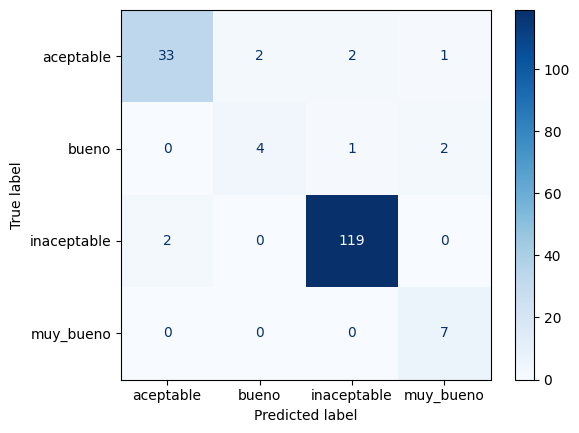

In [25]:
# Obtener matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predecir categorías
y_pred = predecir(x_ts, x_encoder, y_encoder, arbol, probs=False)

# Construir y mostrar la matriz de confusión
cm = confusion_matrix(y_ts, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_encoder.classes_)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues);


Y vemos que:

- Del total de 7 datos categoría "muy_bueno" el modelo clasifica correctamente el 100%. Recordemos que esta es una categoría minoritaria
- Del total de 121 datos categoría "inaceptable" el modelo clasifica correctamente 119 datos (98.3%)
- Para la categoría "aceptable" el desempeño es bueno, clasificando correctamente 33/38 datos (86%)
- Y la categoría con el peor desempeño es la categoría "bueno" donde sólo 4/7 datos (57.1%) fueron clasificados correctamente

Lo anterior resalta la importancia de contar idealmente con sets de datos balanceados. De no ser posible se pueden usar otras técnicas que permitan compensar este desbalanceo.